## Tarea: Modelos Ingenuos y primeros pasos para construir un modelo probabilístico.


¡Bienvenido(a)!
Te invitamos a realizar el primer trabajo.
- Objetivo: Ajustar modelos ingenuos a una serie de tiempo. Interpretar los resultados y analizar si los residuos presentan estructura
- Tipo de actividad: Individual
- Tipo de evaluación: Sumativa 
- Puntaje: 100 puntos
- Calificación: Escala de 1 a 7, con una exigencia de 50%. La nota mínima para aprobar es 4.0.

## Enunciado

### Introducción

Esta tarea está pensada en abordar y profundizar los métodos ingenuos para ajustar series temporales, así como también analizar si existe evidencia empírica que un modelo de serie de tiempo debería ser adecuado. Específicamente, se ajustarán modelos de
suavizamiento exponencial y métodos de descomposición, así como también se analizarán las funciones de autocorrelación (simple y parcial) muestrales. Finalmente, se dan los primeros pasos en comprender como este tipo de modelos nos permite predecir observaciones futuras, cuantificando, de cierto modo el error o la calidad del ajuste.

### Descripción del problema

La serie *IPC.xlsx* (disponible en la plataforma) corresponde al índice de precio al consumidor de Chile desde abril de 1989 hasta junio de 2023 medido de forma mensual. El objetivo del análisis es predecir el IPC para el segundo semestre de 2023, es
decir, de julio a diciembre de 2023.

In [1]:
import numpy as np
import pandas as pd
from darts import TimeSeries
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_squared_error
from scipy.stats import boxcox


from darts.utils.statistics import plot_acf, plot_pacf, acf, pacf

import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

Dispones de un archivo Excel "IPC.xlsx" que contiene columnas 'YEAR', 'MONTH', e 'IPC'. Tu tarea es preparar estos datos para un análisis de series temporales utilizando pandas y la biblioteca darts. Sigue los pasos especificados a continuación, utilizando las variables y métodos indicados:

* Utiliza pd.read_excel() para cargar los datos desde el archivo en la variable df.

* Combina 'YEAR' y 'MONTH' en una nueva columna 'Fecha' en df, configurándola con el día 1 de cada mes. Emplea pd.to_datetime() para esta conversión.

* Establece 'Fecha' como índice de df usando DataFrame.set_index() y elimina 'YEAR' y 'MONTH' de df usando DataFrame.drop().

* Transforma la columna 'IPC' de df en una serie temporal en la variable ipc usando TimeSeries.from_series() de darts.


* Separa ipc en entrenamiento (ipc_train) y validación (ipc_val) antes del '2023-01-01' con TimeSeries.split_before().

In [ ]:
# Formato de Serie de Tiempo: Guardar la información en
# df: data frame con las indicaciones propuestas
# ipc: serie completa
# ipc_train: serie entrenamiento
# ipc_val: serie validación

# your code here
path = "data/raw/w2_IPC.xlsx"
df = pd.read_excel(path, sheet_name="Sheet 1")
df["Fecha"] = pd.to_datetime(df[["YEAR", "MONTH"]].assign(DAY=1))
df.set_index("Fecha", inplace=True)
df.drop(columns=["YEAR", "MONTH"], inplace=True)
ipc = TimeSeries.from_series(df["IPC"])
ipc_train, ipc_val = ipc.split_before(pd.Timestamp("2023-01-01"))

In [3]:
# Prueba oculta: Pruebas para medir si el archivo es correctamente cargado y el formato es correcto

In [4]:
# Prueba oculta: Pruebas para medir si el formato es correcto

In [5]:
# Prueba oculta: sobre si las fechas está correctamente indexada


Gráficar la serie temporal y responder a la siguiente pregunta: 

¿La serie tiene ausencia de tendencia?

* `respuesta = 'si'`

* `respuesta = 'no'`

* `respuesta = 'no es posible determinar la tendencia desde la gráfica de la serie'`

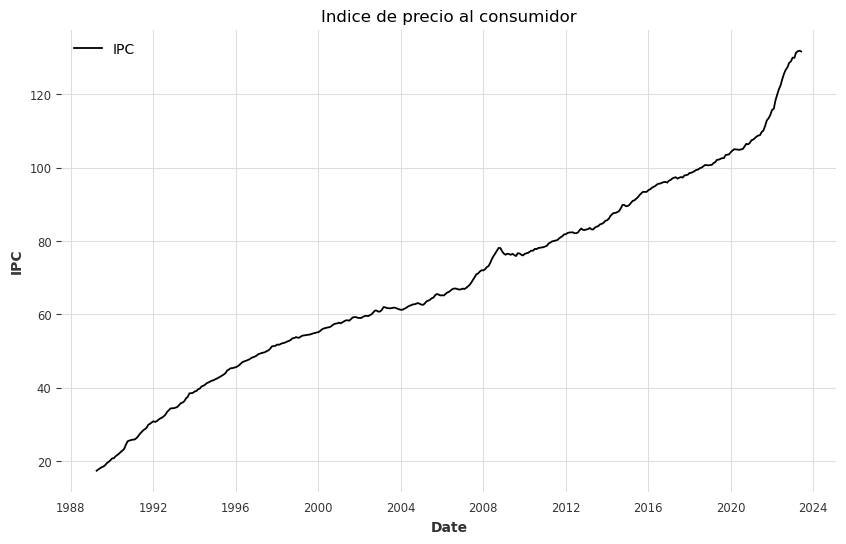

In [6]:
# Guardar respuesta:
# respuesta: indicar la respuesta a la pregunta

# your code here
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['IPC'], label='IPC')
plt.title('Indice de precio al consumidor')
plt.xlabel('Date')
plt.ylabel('IPC')
plt.legend()
plt.show()

respuesta = 'no'

In [7]:
# Prueba oculta: sobre la tendencia

Aplique una transformación de Box-Cox a la serie de tiempo completa. ¿El $\lambda$ óptimo corresponde a una transformación logaritmica?


* `respuesta_bc = 'si'`

* `respuesta_bc = 'no'`

* `respuesta_bc = 'no es posible determinar desde el valor de` $\lambda$'

Valor de lambda óptimo: 0.746398030888448


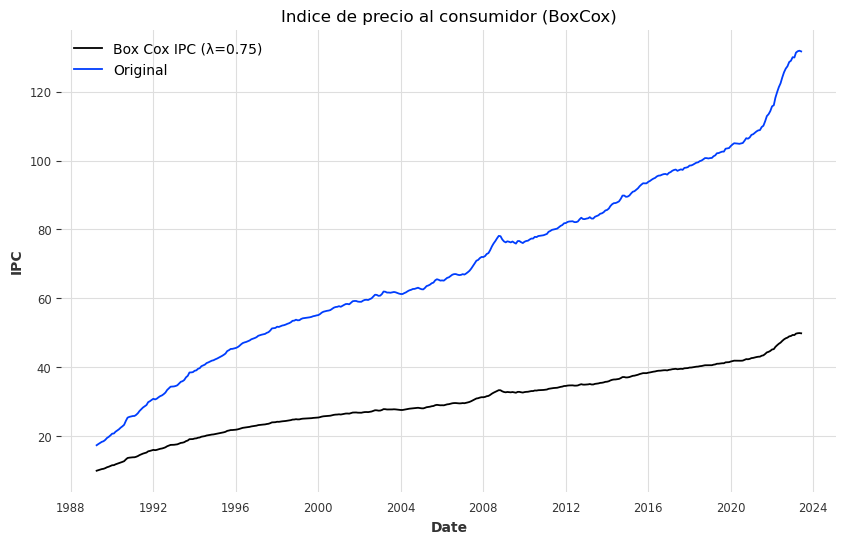

In [8]:
# Guardar información:
# respuesta_bc: indicar respuesta
# lam: valor del lambda óptimo 

# your code here
df["IPC_boxcox"], lam = boxcox(df["IPC"])
print(f"Valor de lambda óptimo: {lam}")


plt.figure(figsize=(10, 6))
plt.plot(df.index, df["IPC_boxcox"], label=f'Box Cox IPC (λ={lam:.2f})')
plt.plot(df.index, df['IPC'], label='Original')
plt.title('Indice de precio al consumidor (BoxCox)')
plt.xlabel('Date')
plt.ylabel('IPC')
plt.legend()
plt.show()

respuesta_bc = 'no'

In [9]:
# Prueba oculta: Prueba para el lambda óptimo


In [10]:
# Prueba oculta: respuesta sobre la transformación

Ajustar un modelo de suavizamiento exponencial de Holt a los datos proporcionados y extraer los parámetros del modelo ajustado.

* Utilice la serie temporal el ipc_train y transformelo a una serie de pandas utilizando pd_series() y guardelo en del conjunto de datos `data_train` para ajustar el modelo de Holt.
* Configure el modelo para que utilice una tendencia aditiva.
* Ajuste el modelo a los datos.
* Extraiga y guarde los valores de los parámetros $\alpha$ y $\beta$ del modelo ajustado.

In [11]:
# Guardar la información:
# train_data: ipc entrenamiento como serie de pandas
# model: modelo de holt
# results: modelo ajustado
# alpha: parámetro alpha del modelo holt
# beta: parámetro beta del modelo holt

# your code here
train_data = ipc_train.pd_series().astype(float)

model = ExponentialSmoothing(train_data, trend='add', seasonal=None, initialization_method="estimated")
results = model.fit(optimized=True)
alpha = float(results.params.get('smoothing_level'))
beta = float(results.params.get('smoothing_trend'))

print(f"alpha {alpha}, beta {beta}")

alpha 0.9999999850980431, beta 0.23635874265962745


In [12]:
# Prueba oculta: Sobre el formato de la serie en pandas


In [13]:
# Prueba oculta: Sobre alpha y beta del modelo de holt 

Realizar predicciones para el conjunto de datos de validación y calcular el error cuadrático medio (MSE) de las predicciones.

* Utilice la serie temporal el ipc_val y transformelo a una serie de pandas utilizando pd_series() y guardelo en del conjunto de datos `data_val` 
* Realice predicciones para el conjunto de datos de validación utilizando el método `forecast_holt`.
* Calcule el error cuadrático medio (MSE) entre las predicciones y los datos de validación reales utilizando `mean_squared_error`.


In [14]:
# Guarda la información:
# val_data: ipc validación como serie de pandas
# forecast_holt: predicciones de los datos de validacion
# mse_holt: Error cuadrático medio de las predicciones

# your code here
data_val = ipc_val.pd_series().astype(float)
val_data = data_val
forecast_holt = results.forecast(len(val_data))
mse_holt = mean_squared_error(val_data, forecast_holt)
print(f"MSE Holt: {mse_holt}")

MSE Holt: 2.851749981140413


In [15]:
# Prueba oculta: sobre la cantidad de valores predichos

In [16]:
# Prueba oculta: sobre el valor del mse 

Aplicar descomposición aditiva a la serie de entrenamiento utilizando un periodo de 12. Guarde la componente de tendencia y estacional usando los métodos `trend` y `seasonal`. Asegurese de eliminar los na con `dropna`.

In [17]:
# Guardar la información:
# decomposition_result: descomposicion de serie de entrenamiento
# estimated_trend: componente tendencia estimada
# estimated_seasonality: componente estacional estimada
# estimated_resid: componente del ruido

# your code here
decomposition_result = seasonal_decompose(train_data, model='additive', period=12)
estimated_trend = decomposition_result.trend.dropna()
estimated_seasonality = decomposition_result.seasonal.dropna()
estimated_resid = decomposition_result.resid.dropna()

In [18]:
#Pruebas de formato

Considere un modelo de Regresión Lineal para ajustar la tendencia. Para esto utilice lo siguiente

`X = np.arange(len(estimated_trend)).reshape(-1, 1)`

`y = estimated_trend.values`

`dates_jan_jun_2023 = pd.date_range(start='2023-01-01', end='2023-06-01', freq='MS')`

`X_future = np.arange(len(estimated_trend), len(estimated_trend) + len(dates_jan_jun_2023)).reshape(-1, 1)`

Luego, haga lo siguiente:
* Cree el modelo de regresión lineal para la tendencia, ajustelo y haga la predicción para `X_future`.
* Considere la componente estacional para los meses de Enero a Junio del 2023.
* Sumar la predicción de la tendencia y la componente estacional. Luego convertirlo en una Serie de Pandas.
* Calcular el error cuadrático medio con respecto a la serie de validación.

In [19]:
# Guardar información
# trend_model: modelo de regresión lineal
# predicted_linear_trend: predicciones de la tendencia lineal para las fechas futuras
# future_seasonality: componente estacional para las fechas futuras
# complete_linear_trend_pred: predicciones completas (tendencia + estacionalidad)
# complete_linear_trend_pred_pd: serie de pandas con las predicciones completas
# mse_linear_trend: error cuadrático medio de las predicciones

# your code here
X = np.arange(len(estimated_trend)).reshape(-1, 1)
y = estimated_trend.values

dates_jan_jun_2023 = pd.date_range(
    start='2023-01-01',
    end='2023-06-01',
    freq='MS'
)

X_future = np.arange(
    len(estimated_trend),
    len(estimated_trend) + len(dates_jan_jun_2023)
).reshape(-1, 1)

trend_model = LinearRegression()
trend_model.fit(X, y)

predicted_linear_trend = trend_model.predict(X_future).reshape(-1)

future_seasonality = estimated_seasonality[-12:].head(
    len(dates_jan_jun_2023)
).values

complete_linear_trend_pred = predicted_linear_trend + future_seasonality

complete_linear_trend_pred_pd = pd.Series(
    complete_linear_trend_pred,
    index=dates_jan_jun_2023
)

mse_linear_trend = mean_squared_error(val_data, complete_linear_trend_pred_pd)

print(f"MSE Linear Trend: {mse_linear_trend}")

MSE Linear Trend: 411.09232965730524


In [20]:
# Prueba oculta: predicción de la tendencia lineal

In [21]:
# Prueba oculta: sobre la extracción de la componente periódica

In [22]:
# Prueba oculta: sobre el mse para la modelo de descomposición (tendencia lineal + parte periódica)

Ahora se debe ajustar una tendencia cúbica. Para esto utilice:

`poly = PolynomialFeatures(degree=3)`

`X_poly = poly.fit_transform(X)`

`X_future_poly = poly.transform(X_future)`

Luego, haga lo siguiente:

* Ajustar la tendencia cúbica usando `LinearRegression`.
* Predecir la tendencia para los meses de Enero y Junio del 2023
* Utilice future_seasonality para hacer las predicciones completas con la tendencia cúbica

In [23]:
# Guardar información
# trend_model: modelo de regresión lineal ajustado a las características polinómicas
# predicted_poly_trend: predicciones de la tendencia cúbica para las fechas futuras
# complete_poly_trend_pred: predicciones completas (tendencia cúbica + estacionalidad)
# complete_poly_trend_pred_pd: serie de pandas con las predicciones completas
# mse_poly_trend: error cuadrático medio de las predicciones cúbicas

# your code here
poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X)

X_future_poly = poly.transform(X_future)

trend_model = LinearRegression()

trend_model.fit(X_poly, y)

predicted_poly_trend = trend_model.predict(X_future_poly).reshape(-1)

complete_poly_trend_pred = predicted_poly_trend + future_seasonality

complete_poly_trend_pred_pd = pd.Series(

    complete_poly_trend_pred,

    index=dates_jan_jun_2023

)

mse_poly_trend = mean_squared_error(val_data, complete_poly_trend_pred_pd)

print(f"MSE Polynomial Trend: {mse_poly_trend}")


MSE Polynomial Trend: 176.88575999329728


In [24]:
# Prueba oculta: sobre el mse para la modelo de descomposición (tendencia cúbica + parte periódica)

In [25]:
# Prueba oculta: sobre el mse para la modelo de descomposición (tendencia cúbica + parte periódica)

Elegir en base al error cuadrático medio en la serie de validación al mejor modelo. Para esto indique alguna de las siguientes respuestas:

`best_model = 'El mejor modelo es el suavizamiento exponencial de Holt'`

`best_model = 'El mejor modelo es el que contiene una tendencia lineal'`

`best_model = 'El mejor modelo es el que contiene una tendencia cúbica'`


In [26]:
# Guardar información:
# best model: indicar su respuesta

# your code here
best_model = 'El mejor modelo es el suavizamiento exponencial de Holt'

In [27]:
# Prueba oculta: Verifica si la respuesta asignada es correcta

Gráficar el ACF para la serie de tiempo completa con un lag máximo de 24. Indicar el comportamiento del ACF:

`ans_acf = 'Decaimiento lento hasta el lag 5, luego tiene lags significativamente igual a cero'`

`ans_acf = 'Solo el lag 1 es significativo'`

`ans_acf = 'Decaimiento lento hasta el lag 24'`

<Figure size 1200x600 with 0 Axes>

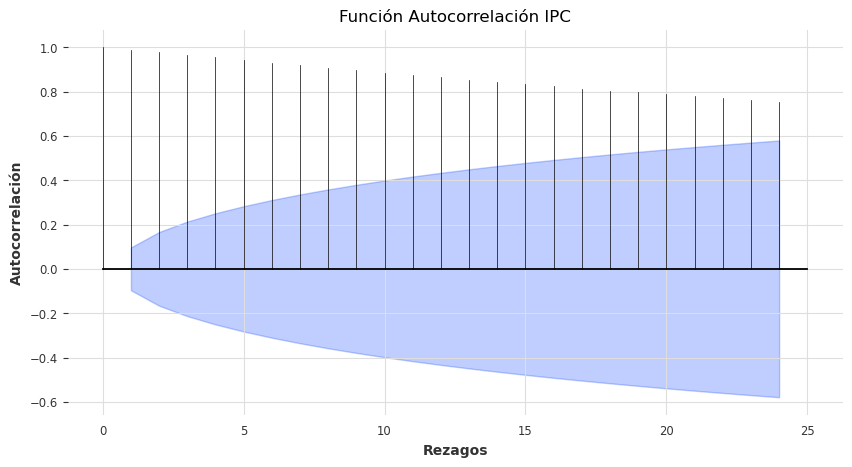

In [28]:
# Guardar la información:
# ans_acf: indicar su respuesta

# your code here
plt.figure(figsize=(12, 6))

plot_acf(ipc, max_lag=24)
plt.title("Función Autocorrelación IPC")
plt.xlabel("Rezagos")
plt.ylabel("Autocorrelación")
plt.show()
ans_acf = 'Decaimiento lento hasta el lag 24'

In [29]:
# Prueba oculta: Verifica si la respuesta asignada sobre el ACF de la serie original es correcta

Gráficar el PACF para la serie de tiempo completa con un lag máximo de 24. Indicar el comportamiento del PACF:

`ans_pacf = 'Decaimiento lento hasta el lag 5, luego tiene lags significativamente igual a cero'`

`ans_pacf = 'Solo el lag 1 es significativo'`

`ans_pacf = 'Decaimiento lento hasta el lag 24'`

<Figure size 1200x600 with 0 Axes>

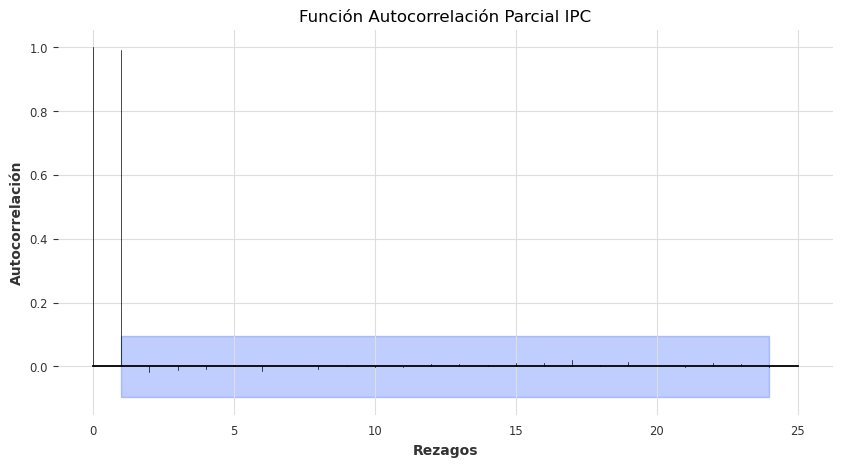

In [30]:
# Guardar la información:
# ans_pacf: indicar su respuesta

# your code here
plt.figure(figsize=(12, 6))
plot_pacf(ipc, max_lag=24)
plt.title("Función Autocorrelación Parcial IPC")
plt.xlabel("Rezagos")
plt.ylabel("Autocorrelación")
plt.show()
ans_pacf = 'Solo el lag 1 es significativo'

In [31]:
# Prueba oculta: sobre el PACF de la serie original

Gráficar el ACF y PACF para la serie de tiempo residual obtenida por método de descomposicion aplicado anteriormente con un lag máximo de 24. 


Indicar el comportamiento del ACF:

`ans_acf_resid = 'Decaimiento rápido y ciclico a 0, desde el lag 12 en adelante son todos significativamente igual a cero'`

`ans_acf_resid = 'Solo el lag 0 y lag 1 son significativos'`

`ans_acf_resid = 'Decaimiento lento hasta el lag 24'`

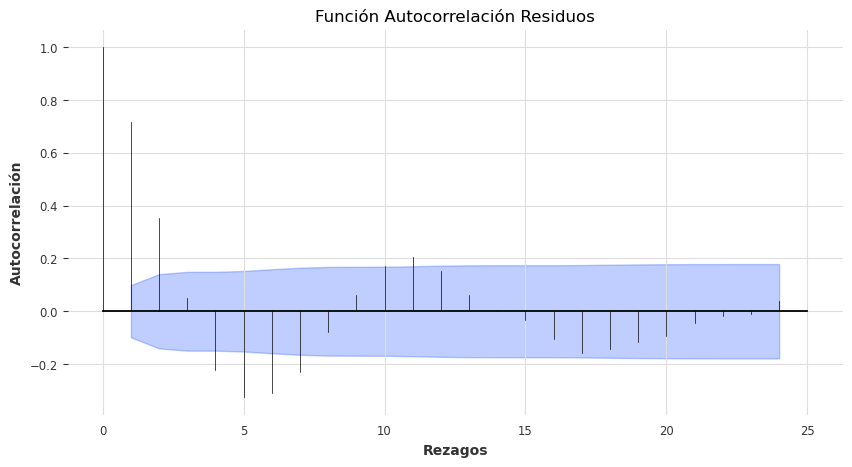

In [32]:
# Guardar la información:
# ruido: serie en formato TimeSeries, usar la función `TimeSeries.from_series`
# ans_acf_resid: indicar su respuesta

# your code here
ruido = TimeSeries.from_series(estimated_resid)
plot_acf(ruido, max_lag=24)
plt.title("Función Autocorrelación Residuos")
plt.xlabel("Rezagos")
plt.ylabel("Autocorrelación")
plt.show()
ans_acf_resid = 'Decaimiento rápido y ciclico a 0, desde el lag 12 en adelante son todos significativamente igual a cero'

In [33]:
# Prueba oculta: Verifica el formato de la serie `ruido`

In [34]:
# Prueba oculta: Verifica si la respuesta asignada sobre el ACF de la serie residual es correcta

A partir de las gráficas anteriores hay evidencia que los residuos del modelo de descomposición tienen información temporal que podria ayudar en mejorar el modelo.

Responda a la pregunta indicando:


* `respuesta_resid = 'si'`

* `respuesta_resid = 'no'`

* `respuesta_resid = 'no es posible determinar la respuesta desde estas gráficas'`

In [35]:
# Guardar información:
# respuesta_resid: indicar su respuesta

# your code here
respuesta_resid = 'si'

In [36]:
# Prueba oculta: sobre la tendencia